In [1]:
import warnings
warnings.filterwarnings('ignore')   # Suppress warnings for clean output

import numpy as np
import pandas as pd
import pickle                        # For saving ML models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

# ─── Handle Imbalanced Data ───────────────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

LIVER DISEASES


In [2]:
df_liver = pd.read_csv("D:\data science\.venv\indian_liver_patient - indian_liver_patient.csv")
df_liver.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df_liver.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [4]:
df_liver.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
df_liver.duplicated().sum()

np.int64(13)

DATA CLEANING

In [6]:
# Drop duplicates
df_liver.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df_liver.shape}')

Shape after removing duplicates: (570, 11)


In [7]:
#Fill missing values with median
df_liver['Albumin_and_Globulin_Ratio'].fillna(
    df_liver['Albumin_and_Globulin_Ratio'].median(), inplace=True
)
df_liver.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [8]:
# Encode Gender: Male=1, Female=0
df_liver['Gender'] = df_liver['Gender'].map({'Male': 1, 'Female': 0})
df_liver['Gender'].value_counts()

Gender
1    430
0    140
Name: count, dtype: int64

In [9]:
df_liver.head() 

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [10]:
df_liver.info()


<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         570 non-null    int64  
 1   Gender                      570 non-null    int64  
 2   Total_Bilirubin             570 non-null    float64
 3   Direct_Bilirubin            570 non-null    float64
 4   Alkaline_Phosphotase        570 non-null    int64  
 5   Alamine_Aminotransferase    570 non-null    int64  
 6   Aspartate_Aminotransferase  570 non-null    int64  
 7   Total_Protiens              570 non-null    float64
 8   Albumin                     570 non-null    float64
 9   Albumin_and_Globulin_Ratio  570 non-null    float64
 10  Dataset                     570 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 53.4 KB


In [11]:
df_liver.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000
mean,44.849123,0.754386,3.321754,1.497544,291.750877,79.728070,109.380702,6.496316,3.148947,0.948018,1.287719
std,16.242182,0.430829,6.267941,2.833231,245.291859,181.471697,290.880671,1.088300,0.796813,0.318510,0.453097
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.950000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.000000,86.750000,7.200000,3.800000,1.100000,2.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


EDA - CORRELATION & TARGET

In [12]:
df_liver.corr(numeric_only=True)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
Age,1.000000,0.058237,0.011500,0.007050,0.081673,-0.083383,-0.016753,-0.197052,-0.271170,-0.215654,-0.138093
Gender,0.058237,1.000000,0.090298,0.101730,-0.023014,0.084317,0.081497,-0.085895,-0.091369,-0.005604,-0.078501
Total_Bilirubin,0.011500,0.090298,1.000000,0.874116,0.206239,0.217471,0.238678,-0.008588,-0.224124,-0.207646,-0.224430
Direct_Bilirubin,0.007050,0.101730,0.874116,1.000000,0.234609,0.237450,0.258489,-0.000875,-0.230751,-0.201412,-0.250666
Alkaline_Phosphotase,0.081673,-0.023014,0.206239,0.234609,1.000000,0.126830,0.167230,-0.030048,-0.168318,-0.236058,-0.187560
Alamine_Aminotransferase,-0.083383,0.084317,0.217471,0.237450,0.126830,1.000000,0.791857,-0.035193,-0.027973,-0.006537,-0.161917
Aspartate_Aminotransferase,-0.016753,0.081497,0.238678,0.258489,0.167230,0.791857,1.000000,-0.022000,-0.085180,-0.072893,-0.151101
Total_Protiens,-0.197052,-0.085895,-0.008588,-0.000875,-0.030048,-0.035193,-0.022000,1.000000,0.784731,0.233588,0.037794
Albumin,-0.271170,-0.091369,-0.224124,-0.230751,-0.168318,-0.027973,-0.085180,0.784731,1.000000,0.684126,0.166835
Albumin_and_Globulin_Ratio,-0.215654,-0.005604,-0.207646,-0.201412,-0.236058,-0.006537,-0.072893,0.233588,0.684126,1.000000,0.170553


In [13]:
df_liver['Dataset'].value_counts()

Dataset
1    406
2    164
Name: count, dtype: int64

In [14]:
# Replace target: 2 (no disease) → 0
df_liver['Dataset'] = df_liver['Dataset'].replace({2: 0})
df_liver['Dataset'].value_counts()  # 1=liver disease, 0=no disease

Dataset
1    406
0    164
Name: count, dtype: int64

In [15]:
# Correlation with target
df_liver.corr(numeric_only=True)['Dataset'].sort_values(ascending=False)

Dataset                       1.000000
Direct_Bilirubin              0.250666
Total_Bilirubin               0.224430
Alkaline_Phosphotase          0.187560
Alamine_Aminotransferase      0.161917
Aspartate_Aminotransferase    0.151101
Age                           0.138093
Gender                        0.078501
Total_Protiens               -0.037794
Albumin                      -0.166835
Albumin_and_Globulin_Ratio   -0.170553
Name: Dataset, dtype: float64

MODEL TRANING  (WITHOUT OVERSAMPLING)

In [16]:
x = df_liver.drop('Dataset', axis=1)  # Features
y = df_liver['Dataset']                # Target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [17]:
# Unscaled Logistic Regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
print('Unscaled LR Accuracy:', lr.score(x_test, y_test))

Unscaled LR Accuracy: 0.7017543859649122


In [18]:
# Scaled Logistic Regression
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_scaled = LogisticRegression()
lr_scaled.fit(x_train_scaled, y_train)
print('Scaled LR Accuracy:', lr_scaled.score(x_test_scaled, y_test))

Scaled LR Accuracy: 0.7456140350877193


EVALAUTION MATRIX

In [19]:
# Scaled Logistic Regression
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_scaled = LogisticRegression()
lr_scaled.fit(x_train_scaled, y_train)
print('Scaled LR Accuracy:', lr_scaled.score(x_test_scaled, y_test))

Scaled LR Accuracy: 0.7456140350877193


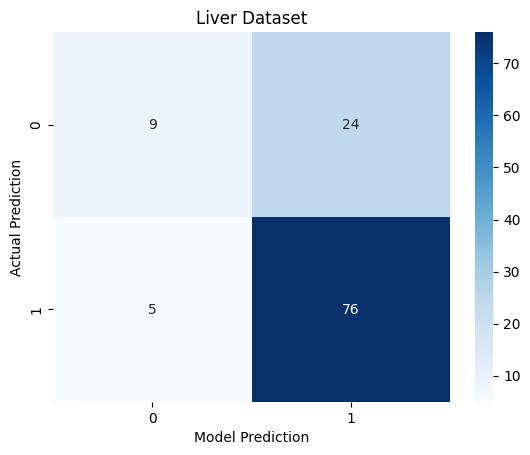

In [20]:
# Confusion Matrix
y_hat = lr_scaled.predict(x_test_scaled)  
cm = confusion_matrix(y_test, y_hat)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Model Prediction')
plt.ylabel('Actual Prediction')
plt.title('Liver Dataset')
plt.show()

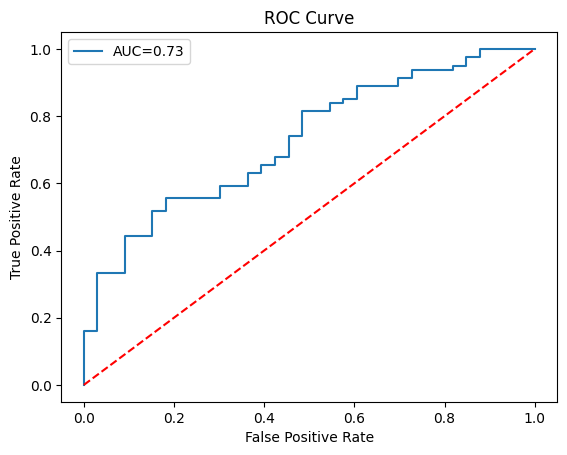

In [21]:
# ROC Curve
y_prob = lr_scaled.predict_proba(x_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
auc_score = roc_auc_score(y_test, y_prob[:, 1])

plt.plot(fpr, tpr, label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

WITH OVERSAMPLE (RANDOM OVERSAMPLER)

In [22]:
x = df_liver.drop('Dataset', axis=1)
y = df_liver['Dataset']

ros = RandomOverSampler()
x_resampled, y_resampled = ros.fit_resample(x, y)
print('After oversampling:')
print(pd.Series(y_resampled).value_counts())

After oversampling:
Dataset
1    406
0    406
Name: count, dtype: int64


In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x_resampled, y_resampled, test_size=0.2, random_state=1
)
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)

x_train: (649, 10)
x_test: (163, 10)


Oversampled LR Accuracy: 0.7668711656441718


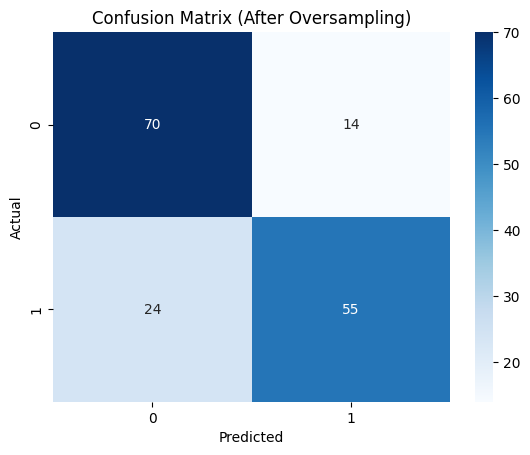

In [24]:
# Scale oversampled data & train new model
scaler2 = StandardScaler()
x_train_scaled = scaler2.fit_transform(x_train)
x_test_scaled = scaler2.transform(x_test)

model = LogisticRegression()
model.fit(x_train_scaled, y_train)
print('Oversampled LR Accuracy:', model.score(x_test_scaled, y_test))

# Confusion Matrix
y_pred = model.predict(x_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (After Oversampling)')
plt.show()


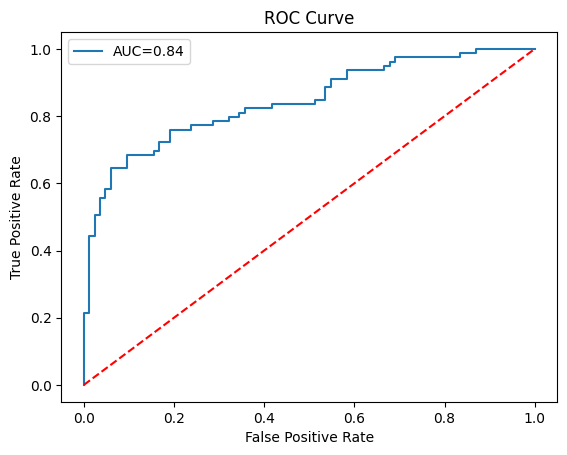

In [25]:
# ROC Curve
y_prob = model.predict_proba(x_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
auc_score = roc_auc_score(y_test, y_prob[:, 1])

plt.plot(fpr, tpr, label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

SAVE MODEL & CLEAN DATA 

In [26]:
# Save pickle
liver_model = {
    'model': model,
    'scaler': scaler,
    'feature_names': x.columns.tolist()
}
with open('liver_model.pkl', 'wb') as f:
    pickle.dump(liver_model, f)
print(' liver_model.pkl saved')

 liver_model.pkl saved


In [27]:
# Save cleaned CSV
df_liver.to_csv('Liver_cleaned_data.csv', index=False)
print(' Liver_cleaned_data.csv saved')
pd.read_csv('Liver_cleaned_data.csv').head()

 Liver_cleaned_data.csv saved


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


KIDNEY DISEASE PREDICTION

In [28]:
df_kidney = pd.read_csv("D:\data science\.venv\kidney_disease - kidney_disease.csv")
df_kidney

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [29]:
df_kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

DATA CLEANING

In [30]:
# Replace '?' with NaN
df_kidney.replace('?', np.nan, inplace=True)

In [31]:
# Convert pcv, wc, rc from object to numeric
df_kidney['pcv'] = pd.to_numeric(df_kidney['pcv'], errors='coerce')
df_kidney['wc'] = pd.to_numeric(df_kidney['wc'], errors='coerce')
df_kidney['rc'] = pd.to_numeric(df_kidney['rc'], errors='coerce')

In [32]:
# Drop 'id' column — not a medical feature
df_kidney.drop('id', axis=1, inplace=True)
df_kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [33]:
df_kidney.duplicated().sum()

np.int64(0)

In [34]:
# Fill NaN values for numeric columns with median
numeric_columns = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
for col in numeric_columns:
    df_kidney[col] = pd.to_numeric(df_kidney[col], errors='coerce')
    df_kidney[col].fillna(df_kidney[col].median(), inplace=True)

# Fill NaN for categorical columns with mode (most frequent value)
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in cat_cols:
    df_kidney[col].fillna(df_kidney[col].mode()[0], inplace=True)

df_kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

In [35]:
df_kidney.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000
mean,51.562500,76.575000,1.017712,0.90000,0.395000,145.062500,56.693000,2.997125,137.631250,4.577250,12.54250,39.082500,8298.500000,4.737750
std,16.982996,13.489785,0.005434,1.31313,1.040038,75.260774,49.395258,5.628886,9.206332,2.821357,2.71649,8.162245,2529.593814,0.841439
min,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.10000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.87500,34.000000,6975.000000,4.500000
50%,55.000000,80.000000,1.020000,0.00000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.65000,40.000000,8000.000000,4.800000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,14.62500,44.000000,9400.000000,5.100000
max,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.80000,54.000000,26400.000000,8.000000


ENCODING CATEGORICAL DATA

In [36]:
# LabelEncoder converts text to numbers:
# e.g. 'normal'→1, 'abnormal'→0, 'yes'→1, 'no'→0

from sklearn.preprocessing import LabelEncoder

cat_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_kidney[col] = le.fit_transform(df_kidney[col])
    encoders[col] = le

df_kidney.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,ckd
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,ckd
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,ckd
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,ckd
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,ckd


In [37]:
# Encode target: ckd=1, notckd=0
df_kidney['classification'] = df_kidney['classification'].map({'ckd': 1, 'notckd': 0})
df_kidney['classification'].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

EDA CORRELATION

In [38]:
df_kidney.corr(numeric_only=True)['classification'].sort_values(ascending=False)

classification    1.000000
htn               0.590438
dm                0.559060
al                0.531562
appet             0.393341
bgr               0.379321
pe                0.375154
bu                0.369393
ane               0.325396
su                0.294555
bp                0.293693
sc                0.291245
pcc               0.265313
cad               0.236088
age               0.227842
ba                0.186871
wc                0.177571
pot               0.065218
rbc              -0.282642
sod              -0.334900
pc               -0.375154
rc               -0.566163
sg               -0.659504
pcv              -0.673129
hemo             -0.726368
Name: classification, dtype: float64

MODEL TRANING WITH (OVER SAMPLING)

In [39]:
x = df_kidney.drop('classification', axis=1)  # Features
y = df_kidney['classification']                 # Target

# Oversample minority class
ros = RandomOverSampler()
x_resampled, y_resampled = ros.fit_resample(x, y)
print('After oversampling:')
print(pd.Series(y_resampled).value_counts())

After oversampling:
classification
1    250
0    250
Name: count, dtype: int64


In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    x_resampled, y_resampled, test_size=0.2, random_state=1
)
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (400, 24)
x_test: (100, 24)
y_train: (400,)
y_test: (100,)


In [41]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

Accuracy : 0.99
Precision: 1.0
Recall   : 0.9761904761904762
F1 Score : 0.9879518072289156


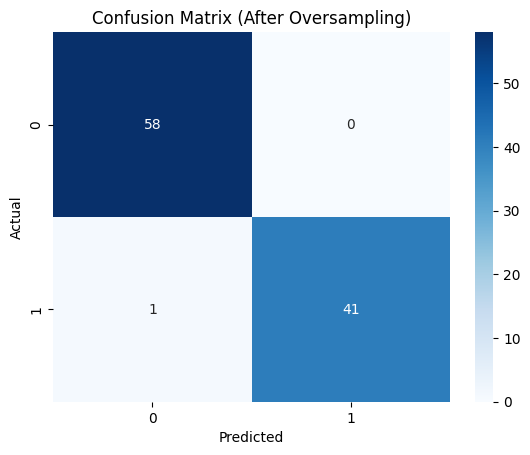

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (After Oversampling)')
plt.show()

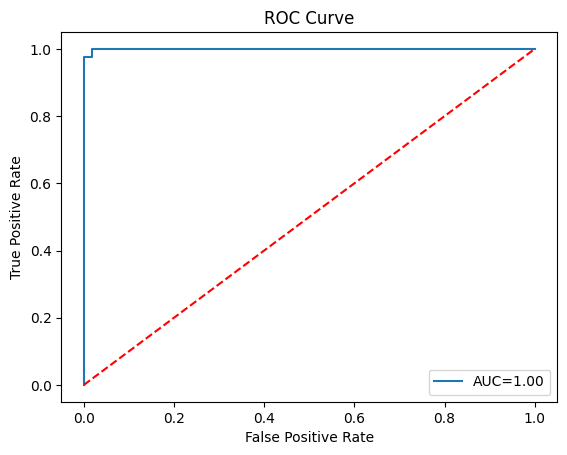

In [43]:
# ROC Curve
y_prob = model.predict_proba(x_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
auc_score = roc_auc_score(y_test, y_prob[:, 1])

plt.plot(fpr, tpr, label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

WITHOUT OVERSAMLING (COMPARISON)

In [44]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=0.2, random_state=1)

# Unscaled
lr = LogisticRegression()
lr.fit(x_train2, y_train2)
print('Unscaled LR:', lr.score(x_test2, y_test2))

# Scaled
scaler2 = StandardScaler()
x_train2_sc = scaler2.fit_transform(x_train2)
x_test2_sc = scaler2.transform(x_test2)

lr_scaled = LogisticRegression()
lr_scaled.fit(x_train2_sc, y_train2)
print('Scaled LR  :', lr_scaled.score(x_test2_sc, y_test2))

Unscaled LR: 0.9
Scaled LR  : 0.9875


In [45]:
y_hat = lr_scaled.predict(x_test2_sc)

print(f'Accuracy : {accuracy_score(y_test2, y_hat)}')
print(f'Precision: {precision_score(y_test2, y_hat)}')
print(f'Recall   : {recall_score(y_test2, y_hat)}')
print(f'F1 Score : {f1_score(y_test2, y_hat)}')

Accuracy : 0.9875
Precision: 1.0
Recall   : 0.9787234042553191
F1 Score : 0.989247311827957


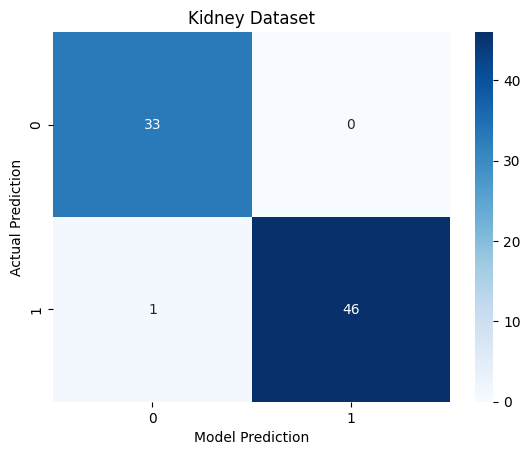

In [46]:
cm = confusion_matrix(y_test2, y_hat)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Model Prediction')
plt.ylabel('Actual Prediction')
plt.title('Kidney Dataset')
plt.show()

AUC: 1.0


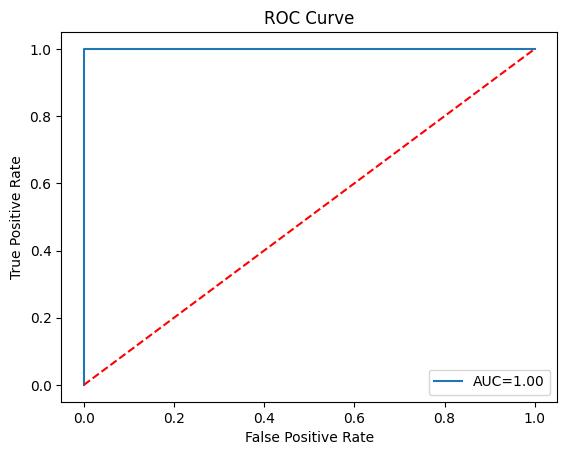

In [47]:
y_prob2 = lr_scaled.predict_proba(x_test2_sc)
fpr, tpr, _ = roc_curve(y_test2, y_prob2[:, 1])
auc_score = roc_auc_score(y_test2, y_prob2[:, 1])
print('AUC:', auc_score)

plt.plot(fpr, tpr, label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

SAVE MODEL & CLEANED DATA

In [48]:
kidney_disease = {
    'model': lr_scaled,
    'scaler': scaler2,
    'encoders': encoders,
    'feature_names': x.columns.tolist()
}

with open('kidney_model.pkl', 'wb') as f:
    pickle.dump(kidney_disease, f)
print(' kidney_model.pkl saved')

 kidney_model.pkl saved


In [49]:
df_kidney.to_csv('Kidney_cleaned_data.csv', index=False)
print(' Kidney_cleaned_data.csv saved')
pd.read_csv('Kidney_cleaned_data.csv').head()

 Kidney_cleaned_data.csv saved


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


PARKINSON'S DISEASE PREDICTION 

In [50]:
df_parkS = pd.read_csv("D:\data science\.venv\parkinsons - parkinsons.csv")
df_parkS

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [51]:
df_parkS.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [52]:
df_parkS.duplicated().sum()

np.int64(0)

In [53]:
df_parkS.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [54]:
df_parkS.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


DATA CLEANING

In [55]:
# Drop 'name' column — patient name is not a feature
df_parkS.drop('name', axis=1, inplace=True)
df_parkS.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [56]:
df_parkS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       195 non-null    float64
 1   MDVP:Fhi(Hz)      195 non-null    float64
 2   MDVP:Flo(Hz)      195 non-null    float64
 3   MDVP:Jitter(%)    195 non-null    float64
 4   MDVP:Jitter(Abs)  195 non-null    float64
 5   MDVP:RAP          195 non-null    float64
 6   MDVP:PPQ          195 non-null    float64
 7   Jitter:DDP        195 non-null    float64
 8   MDVP:Shimmer      195 non-null    float64
 9   MDVP:Shimmer(dB)  195 non-null    float64
 10  Shimmer:APQ3      195 non-null    float64
 11  Shimmer:APQ5      195 non-null    float64
 12  MDVP:APQ          195 non-null    float64
 13  Shimmer:DDA       195 non-null    float64
 14  NHR               195 non-null    float64
 15  HNR               195 non-null    float64
 16  status            195 non-null    int64  
 1

EDA AND CORRELATION WITH TARGET

In [57]:
df_parkS.corr(numeric_only=True)['status'].sort_values(ascending=False)

status              1.000000
spread1             0.564838
PPE                 0.531039
spread2             0.454842
MDVP:Shimmer        0.367430
MDVP:APQ            0.364316
Shimmer:APQ5        0.351148
MDVP:Shimmer(dB)    0.350697
Shimmer:APQ3        0.347617
Shimmer:DDA         0.347608
D2                  0.340232
MDVP:Jitter(Abs)    0.338653
RPDE                0.308567
MDVP:PPQ            0.288698
MDVP:Jitter(%)      0.278220
MDVP:RAP            0.266668
Jitter:DDP          0.266646
DFA                 0.231739
NHR                 0.189429
MDVP:Fhi(Hz)       -0.166136
HNR                -0.361515
MDVP:Flo(Hz)       -0.380200
MDVP:Fo(Hz)        -0.383535
Name: status, dtype: float64

MODEL TRANING

In [58]:
x = df_parkS.drop('status', axis=1)  # Features (22 voice measurements)
y = df_parkS['status']                # Target (1=Parkinsons, 0=Healthy)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)

x_train: (156, 22)
x_test: (39, 22)


In [59]:
# Unscaled Logistic Regression
lr1 = LogisticRegression()
lr1.fit(x_train, y_train)
print('Unscaled LR Accuracy:', lr1.score(x_test, y_test))

Unscaled LR Accuracy: 0.8205128205128205


In [60]:
# Scaled Logistic Regression
scaler3 = StandardScaler()
x_train_scaled3 = scaler3.fit_transform(x_train)
x_test_scaled3 = scaler3.transform(x_test)

lr_scaled3 = LogisticRegression()
lr_scaled3.fit(x_train_scaled3, y_train)
print('Scaled LR Accuracy:', lr_scaled3.score(x_test_scaled3, y_test))

Scaled LR Accuracy: 0.8461538461538461


EVALUATION METRICS

In [61]:
y_hat3 = lr_scaled3.predict(x_test_scaled3)

print(f'Accuracy : {accuracy_score(y_test, y_hat3)}')
print(f'Precision: {precision_score(y_test, y_hat3)}')
print(f'Recall   : {recall_score(y_test, y_hat3)}')
print(f'F1 Score : {f1_score(y_test, y_hat3)}')

Accuracy : 0.8461538461538461
Precision: 0.896551724137931
Recall   : 0.896551724137931
F1 Score : 0.896551724137931


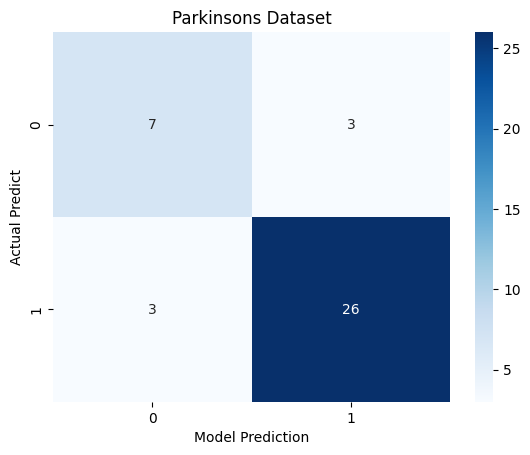

In [62]:
# Confusion Matrix
cm1 = confusion_matrix(y_test, y_hat3)
sns.heatmap(cm1, annot=True, cmap='Blues')
plt.xlabel('Model Prediction')
plt.ylabel('Actual Predict')
plt.title('Parkinsons Dataset')
plt.show()

AUC: 0.903448275862069


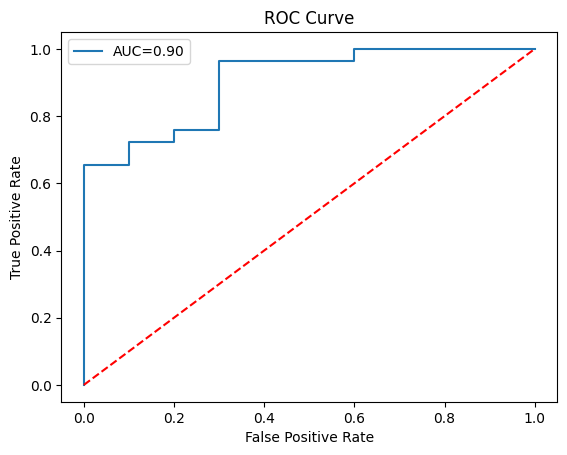

In [63]:
# ROC Curve
y_prob1 = lr_scaled3.predict_proba(x_test_scaled3)
fpr, tpr, thresholds = roc_curve(y_test, y_prob1[:, 1])
auc_score1 = roc_auc_score(y_test, y_prob1[:, 1])
print('AUC:', auc_score1)

plt.plot(fpr, tpr, label=f'AUC={auc_score1:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

SAVE MODEL & CLEANED DATA

In [65]:
parkinson_data = {
    'model': lr_scaled3,
    'scaler': scaler3,
    'feature_names': x.columns.tolist()
}

with open('parkinson_model.pkl', 'wb') as f:
    pickle.dump(parkinson_data, f)
print('parkinson_model.pkl saved')

parkinson_model.pkl saved


In [66]:
df_parkS.to_csv('Parkinsion_cleaned_data.csv', index=False)
print('✅ Parkinsion_cleaned_data.csv saved')
pd.read_csv('Parkinsion_cleaned_data.csv').head()

✅ Parkinsion_cleaned_data.csv saved


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
